# Task 6: Introduction to Deep Learning & Artificial Neural Networks (ANN)

## Objective
Transitioning from traditional Machine Learning (Tasks 1-5) to Deep Learning using TensorFlow/Keras. This task involves building a multi-layer Artificial Neural Network (ANN) to perform binary classification on the Breast Cancer dataset.

## Key Improvements in this Implementation:
* **Architecture Enhancement:** Integrated `Dropout` layers to prevent model overfitting (Advanced Objective).
* **Training Optimization:** Implemented `EarlyStopping` to automatically halt training when validation performance stops improving, saving compute resources.
* **Comprehensive Visualization:** Added both accuracy and loss trajectory graphs for a complete view of model convergence.
* **Automated Benchmarking:** Included an automated script to compare the ANN directly against Logistic Regression (Task 4) and Random Forest (Task 5).

Step 1: Install & Import Required Libraries

In [1]:
# Suppress TensorFlow informational warnings for a cleaner output
import os # Import operating system module
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Set environment variable to hide TF info/warning logs

# Import standard data manipulation and mathematical libraries
import pandas as pd # Import pandas for dataframes (though using numpy arrays mostly here)
import numpy as np # Import numpy for numerical operations and array handling

# Import visualization libraries
import matplotlib.pyplot as plt # Import pyplot for creating static, interactive, and animated visualizations
import seaborn as sns # Import seaborn for statistical data visualization and better aesthetics

# Import Scikit-Learn modules for data handling and traditional ML comparison
from sklearn.datasets import load_breast_cancer # Import the breast cancer dataset directly from scikit-learn
from sklearn.model_selection import train_test_split # Import function to split data into training and testing sets
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling (Z-score normalization)
from sklearn.linear_model import LogisticRegression # Import Logistic Regression for baseline comparison (Task 4)
from sklearn.ensemble import RandomForestClassifier # Import Random Forest for ensemble comparison (Task 5)
from sklearn.metrics import accuracy_score, classification_report # Import metrics to evaluate model performance

# Import TensorFlow and Keras modules for Deep Learning
import tensorflow as tf # Import the main TensorFlow library
from tensorflow.keras.models import Sequential # Import the Sequential API to build models layer-by-layer
from tensorflow.keras.layers import Dense, Dropout # Import Dense (fully connected) and Dropout (regularization) layers
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping to halt training when validation stops improving

Step 2: Load and Preprocess the Dataset

In [2]:
# 1. Load Dataset
print("Loading Breast Cancer dataset...") # Print status message
data = load_breast_cancer() # Instantiate the dataset object
X = data.data # Extract the feature matrix (30 numerical features)
y = data.target # Extract the target labels (0 = malignant, 1 = benign)

# 2. Train-Test Split
# Split the dataset: 80% for training the model, 20% for testing its generalization
X_train, X_test, y_train, y_test = train_test_split(
    X, # Pass the feature matrix
    y, # Pass the target array
    test_size=0.2, # Allocate exactly 20% of the data to the test set
    random_state=42, # Set a random seed to ensure reproducible splits across runs
    stratify=y # Ensure the proportion of 0s and 1s remains the same in train and test sets
)

# 3. Feature Scaling (Critical for Neural Networks)
scaler = StandardScaler() # Initialize the StandardScaler object
X_train_scaled = scaler.fit_transform(X_train) # Calculate mean/variance from training data and apply transformation
X_test_scaled = scaler.transform(X_test) # Apply the already calculated training mean/variance to the test data

print(f"Training features shape: {X_train_scaled.shape}") # Display the dimensions of the training data
print(f"Testing features shape: {X_test_scaled.shape}") # Display the dimensions of the testing data

Loading Breast Cancer dataset...
Training features shape: (455, 30)
Testing features shape: (114, 30)


Step 3: Build and Compile the Neural Network

In [3]:
# Initialize the Sequential model (a linear stack of layers)
model = Sequential()

# Input Layer & First Hidden Layer
# Add a Dense (fully connected) layer with 16 neurons
# activation='relu' introduces non-linearity (Rectified Linear Unit)
# input_shape defines the number of features coming in (30 features)
model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Regularization Layer (Improvement)
# Dropout randomly sets 20% of the input units to 0 at each step during training, preventing overfitting
model.add(Dropout(0.2))

# Second Hidden Layer
# Add another Dense layer with 8 neurons to further extract representations
model.add(Dense(8, activation='relu'))

# Regularization Layer (Improvement)
# Drop out 20% of connections from the second hidden layer
model.add(Dropout(0.2))

# Output Layer
# Add a single neuron for binary classification
# activation='sigmoid' squashes the output between 0 and 1 (representing probability)
model.add(Dense(1, activation='sigmoid'))

# Compile the Model
# Configure the learning process before training
model.compile(
    optimizer='adam', # Use Adam optimizer (Adaptive Moment Estimation) for efficient gradient descent
    loss='binary_crossentropy', # Use binary crossentropy as the loss function for binary classification
    metrics=['accuracy'] # Track classification accuracy during training and testing
)

# Display a summary of the model architecture, layers, and parameter counts
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Step 4: Train the Neural Network

In [4]:
# Define the EarlyStopping callback (Improvement)
# This monitors the validation loss and stops training if it doesn't improve for 10 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss', # The metric to monitor
    patience=10, # Number of epochs to wait for improvement before stopping
    restore_best_weights=True, # Revert to the model weights from the epoch with the lowest validation loss
    verbose=1 # Print a message when training is stopped early
)

# Train the model and store the training history
print("Starting model training...") # Print status message
history = model.fit(
    X_train_scaled, # The scaled training features
    y_train, # The training labels
    epochs=100, # Set a higher maximum number of epochs (EarlyStopping will likely stop it sooner)
    batch_size=16, # Update weights after passing 16 samples through the network
    validation_split=0.2, # Hold out 20% of the *training* data internally to validate at each epoch
    callbacks=[early_stop], # Pass the early stopping object to the training loop
    verbose=1 # Show a progress bar for every epoch
)

Starting model training...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3929 - loss: 0.7978 - val_accuracy: 0.5604 - val_loss: 0.7117
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5989 - loss: 0.6943 - val_accuracy: 0.7473 - val_loss: 0.6324
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.6283 - val_accuracy: 0.8352 - val_loss: 0.5743
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7967 - loss: 0.5735 - val_accuracy: 0.8681 - val_loss: 0.5119
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8736 - loss: 0.4977 - val_accuracy: 0.9341 - val_loss: 0.4189
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9066 - loss: 0.3743 - val_accuracy: 0.9451 - val_loss: 0.3151
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.3186 - val_accuracy: 0.9341 - val_loss: 0.2385
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9313 - loss: 0.2

Step 5: Evaluate and Visualize Performance


Final Neural Network Accuracy on Test Set: 94.74%
Final Neural Network Loss on Test Set: 0.1110


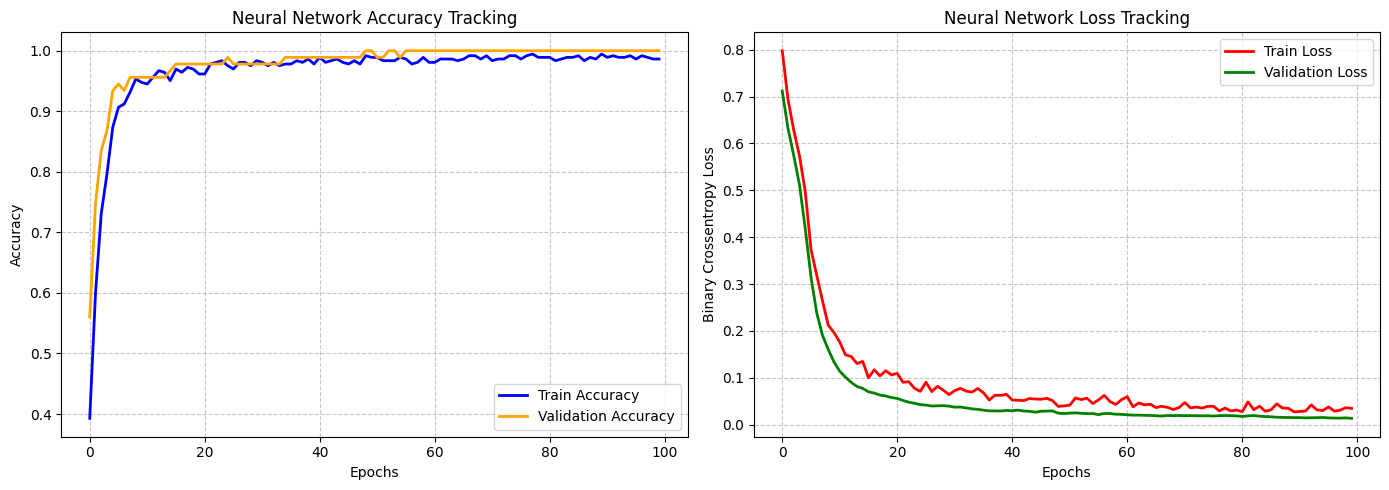

In [5]:
# 1. Final Evaluation on unseen Test Data
# Calculate the final loss and accuracy on the testing set
loss, ann_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Neural Network Accuracy on Test Set: {ann_accuracy * 100:.2f}%") # Print the formatted accuracy
print(f"Final Neural Network Loss on Test Set: {loss:.4f}") # Print the formatted loss

# 2. Visualization
# Set up a matplotlib figure with 1 row and 2 columns for subplots
plt.figure(figsize=(14, 5))

# Subplot 1: Model Accuracy
plt.subplot(1, 2, 1) # Select the first subplot
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2) # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2) # Plot val accuracy
plt.title('Neural Network Accuracy Tracking') # Add a title
plt.xlabel('Epochs') # Label the x-axis
plt.ylabel('Accuracy') # Label the y-axis
plt.legend() # Display the legend
plt.grid(True, linestyle='--', alpha=0.7) # Add a faint grid for readability

# Subplot 2: Model Loss
plt.subplot(1, 2, 2) # Select the second subplot
plt.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2) # Plot training loss
plt.plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2) # Plot val loss
plt.title('Neural Network Loss Tracking') # Add a title
plt.xlabel('Epochs') # Label the x-axis
plt.ylabel('Binary Crossentropy Loss') # Label the y-axis
plt.legend() # Display the legend
plt.grid(True, linestyle='--', alpha=0.7) # Add a faint grid for readability

plt.tight_layout() # Automatically adjust spacing between subplots
plt.show() # Render the plots to the screen

Step 6: Task Comparison (ML vs DL)

Training baseline ML models for comparison...

--- Performance Comparison ---
                       Model  Accuracy
Logistic Regression (Task 4)  0.982456
      Random Forest (Task 5)  0.956140
  Deep Learning ANN (Task 6)  0.947368


/tmp/ipykernel_4456/511839112.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


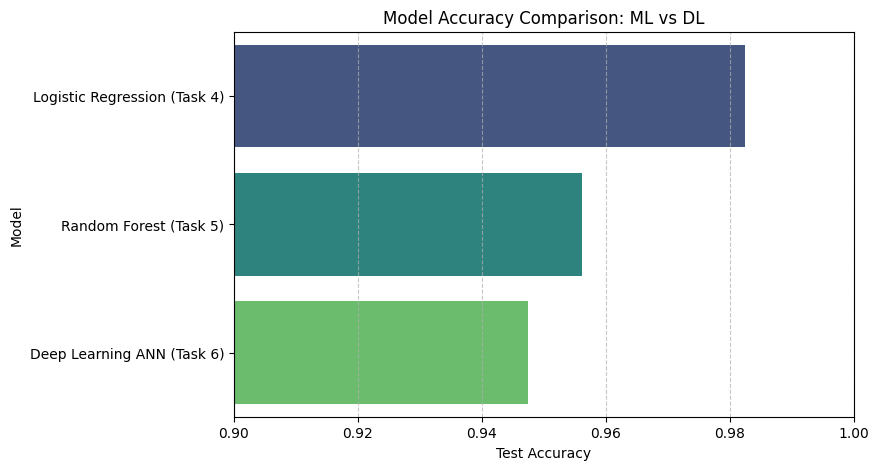

In [6]:
print("Training baseline ML models for comparison...\n") # Print status message

# 1. Train Logistic Regression (Task 4 baseline)
log_reg = LogisticRegression(random_state=42) # Initialize Logistic Regression
log_reg.fit(X_train_scaled, y_train) # Fit the model on the scaled training data
lr_preds = log_reg.predict(X_test_scaled) # Generate predictions on the test set
lr_accuracy = accuracy_score(y_test, lr_preds) # Calculate accuracy

# 2. Train Random Forest (Task 5 baseline)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Initialize Random Forest
rf_model.fit(X_train_scaled, y_train) # Fit the model on the scaled training data
rf_preds = rf_model.predict(X_test_scaled) # Generate predictions on the test set
rf_accuracy = accuracy_score(y_test, rf_preds) # Calculate accuracy

# 3. Compile Results
# Create a dictionary holding the names of the models and their respective accuracies
results = {
    'Model': ['Logistic Regression (Task 4)', 'Random Forest (Task 5)', 'Deep Learning ANN (Task 6)'],
    'Accuracy': [lr_accuracy, rf_accuracy, ann_accuracy]
}

# Convert the dictionary into a pandas DataFrame for neat tabular display
results_df = pd.DataFrame(results)

# Sort the DataFrame by accuracy in descending order to easily see the winner
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# 4. Display the comparison
print("--- Performance Comparison ---") # Print header
print(results_df.to_string(index=False)) # Print the dataframe without index numbers

# Generate a bar chart for visual comparison
plt.figure(figsize=(8, 5)) # Set figure size
# Create a bar plot mapping model names to their accuracies
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison: ML vs DL') # Add title
plt.xlabel('Test Accuracy') # Label x-axis
plt.xlim(0.9, 1.0) # Set x-axis limits to focus on the top end of the percentage scale
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add gridlines for the x-axis
plt.show() # Display the bar chart